# Network Intrusion Classification – Combined Test Pipeline

Combined test pipeline using a **100_000-row stratified sample** of the CICIDS2017 dataset.

**Steps:**
1. Load data & stratified sampling
2. Pre-processing (scaling, label encoding)
3. Feature selection (SelectKBest – ANOVA F-score)
4. Dimensionality reduction (PCA)
5. SMOTE, LDA
6. Model training with GridSearchCV
7. Evaluation & comparison

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score
)

RANDOM_STATE = 42
SAMPLE_SIZE  = 100_000

# 1. Load data, stratified sampling

In [3]:
# Load dataset
try:
    df = pd.read_csv("data/cicids2017_cleaned.csv")
    print(f"Dataset loaded – shape: {df.shape}")
except Exception as e:
    raise RuntimeError(f"Loading failed: {e}")

X_full = df.iloc[:, :-1]
y_full = df.iloc[:, -1]

print("\nClass distribution (full dataset):")
print(y_full.value_counts())

Dataset loaded – shape: (2520751, 53)

Class distribution (full dataset):
Attack Type
Normal Traffic    2095057
DoS                193745
DDoS               128014
Port Scanning       90694
Brute Force          9150
Web Attacks          2143
Bots                 1948
Name: count, dtype: int64


In [4]:
# Stratified sample of 500 rows
sss = StratifiedShuffleSplit(n_splits=1, train_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
sample_idx, _ = next(sss.split(X_full, y_full))

X_sample = X_full.iloc[sample_idx].reset_index(drop=True)
y_sample = y_full.iloc[sample_idx].reset_index(drop=True)

print(f"Sampled rows : {len(X_sample)}")
print(f"Feature count: {X_sample.shape[1]}")
print("\nClass distribution (sample):")
print(y_sample.value_counts())

Sampled rows : 100000
Feature count: 52

Class distribution (sample):
Attack Type
Normal Traffic    83113
DoS                7686
DDoS               5078
Port Scanning      3598
Brute Force         363
Web Attacks          85
Bots                 77
Name: count, dtype: int64


# 2. Pre-processing

In [5]:
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_sample)
print("Classes:", list(le.classes_))

# Remove inf/NaN, drop zero-variance columns, impute medians
X_clean = X_sample.replace([np.inf, -np.inf], np.nan)
X_clean = X_clean.dropna(axis=1, how='all')
X_clean = X_clean.fillna(X_clean.median(numeric_only=True))
X_clean = X_clean.loc[:, X_clean.std() > 0]
print(f"Features after cleaning: {X_clean.shape[1]}")

# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_clean.values, y_encoded,
    test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Classes: ['Bots', 'Brute Force', 'DDoS', 'DoS', 'Normal Traffic', 'Port Scanning', 'Web Attacks']
Features after cleaning: 52
Train: (80000, 52)  |  Test: (20000, 52)


# 3. Scaling, feature selection (for visualization)

Selected 20 features:
  • Flow Duration
  • Bwd Packet Length Max
  • Bwd Packet Length Mean
  • Bwd Packet Length Std
  • Flow IAT Mean
  • Flow IAT Std
  • Flow IAT Max
  • Fwd IAT Total
  • Fwd IAT Std
  • Fwd IAT Max
  • Bwd IAT Std
  • Max Packet Length
  • Packet Length Mean
  • Packet Length Std
  • Packet Length Variance
  • FIN Flag Count
  • Average Packet Size
  • Idle Mean
  • Idle Max
  • Idle Min


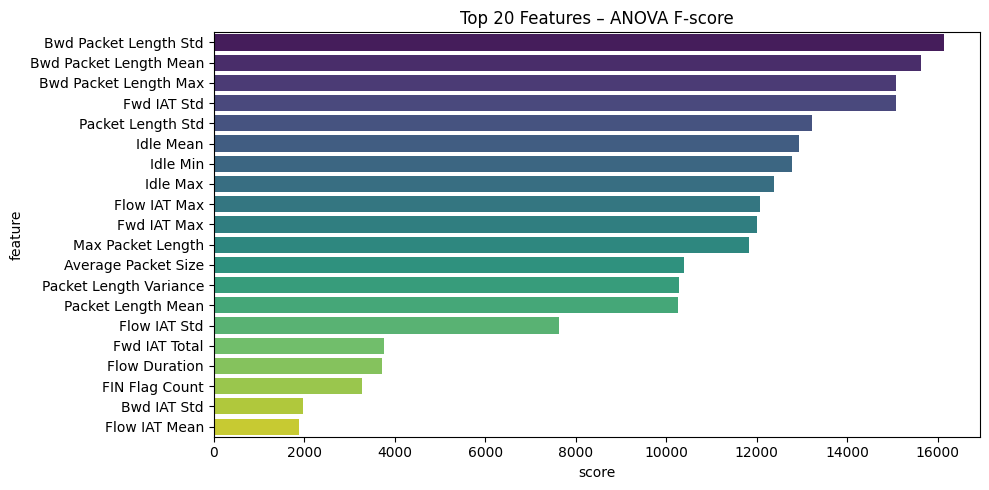

In [6]:
K_FEATURES = 20

# Scale, then select top-K features by ANOVA F-score
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

selector = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_fs = selector.fit_transform(X_train_scaled, y_train)
X_test_fs  = selector.transform(X_test_scaled)

selected_names = X_clean.columns[selector.get_support()].tolist()
print(f"Selected {K_FEATURES} features:")
for f in selected_names:
    print(f"  • {f}")

# Bar chart of feature scores
scores_df = pd.DataFrame({'feature': X_clean.columns, 'score': selector.scores_}) \
              .sort_values('score', ascending=False).head(K_FEATURES)

plt.figure(figsize=(10, 5))
sns.barplot(data=scores_df, x='score', y='feature', palette='viridis')
plt.title(f'Top {K_FEATURES} Features – ANOVA F-score')
plt.tight_layout()
plt.show()

# 4. PCA (defining and visualization)

Cumulative variance (10 components): 99.4%


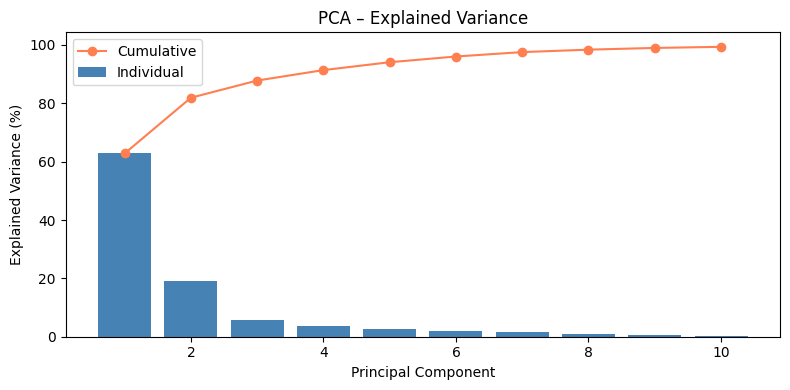

In [7]:
N_COMPONENTS = 10

lda = LinearDiscriminantAnalysis()
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_fs)
X_test_pca  = pca.transform(X_test_fs)

cumulative = np.cumsum(pca.explained_variance_ratio_)
print(f"Cumulative variance ({N_COMPONENTS} components): {cumulative[-1]*100:.1f}%")

# Scree plot
plt.figure(figsize=(8, 4))
plt.bar(range(1, N_COMPONENTS + 1), pca.explained_variance_ratio_ * 100,
        label='Individual', color='steelblue')
plt.plot(range(1, N_COMPONENTS + 1), cumulative * 100,
         marker='o', color='coral', label='Cumulative')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance (%)')
plt.title('PCA – Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

# 5. SMOTE, LDA

In [8]:
sm = SMOTE(sampling_strategy="auto", random_state=RANDOM_STATE, k_neighbors=3)

lda = LinearDiscriminantAnalysis()

# 6. Model training

In [9]:
def train_models(models, test_type):

    results = {}
    for name, config in models.items():
        print(f"Training {name}...")
        # Grid search on FS input
        gs = GridSearchCV(config['pipeline'], config['params'], cv=5, scoring='accuracy', n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_

        # Score on FS test set
        y_pred_fs = best.predict(X_test)

        results['test_type'] = test_type
        results[name] = {
            'best_params': gs.best_params_,
            'cv_score'   : gs.best_score_,
            'f1_score'   : f1_score(y_test, y_pred_fs, average='macro'),
            'y_pred_fs'  : y_pred_fs,
            'report_fs'  : classification_report(y_test, y_pred_fs,
                            labels=np.unique(y_test),
                            target_names=le.inverse_transform(np.unique(y_test)),
                            zero_division=0),
        }
        print(f"{name:22s}  best={gs.best_params_}  CV={gs.best_score_:.4f}")

    print("\nGrid search complete.")
    return results

## Baseline

In [ ]:
baseline_models = {
    'SVM': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('clf', SVC())]),

        'params': {'clf__C': [10_000],
                   'clf__degree': [2],
                   'clf__decision_function_shape': ['ovo'],
                   'clf__class_weight': [None],
                   'feature_selection__k': ['all']}
    },
    'LogisticRegression': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('poly', PolynomialFeatures()),
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('dim_reduction', LinearDiscriminantAnalysis()),
                              ('clf', LogisticRegression(max_iter=10000, 
                                                         random_state=RANDOM_STATE, 
                                                         solver='lbfgs'))]),
        'params': {'clf__C': [1000],
                   'clf__class_weight': [None],
                   'scaler': [StandardScaler()],
                   'poly': [PolynomialFeatures(degree=2), 'passthrough'],
                   'feature_selection__k': ['all']}
    },
    'k-NN': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('dim_reduction', LinearDiscriminantAnalysis()),
                              ('clf', KNeighborsClassifier())]),

        'params': {'clf__n_neighbors': [3], 
                   'clf__leaf_size': [1],
                   'clf__weights': ['distance'], 
                   'clf__metric': ['manhattan'],
                   'clf__p': [1],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': [26]}
    },
    'Naive Bayes': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('clf', GaussianNB())]),

        'params': {'clf__var_smoothing': [1e-5],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': ['all']}
    },
    'DecisionTree': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('clf', DecisionTreeClassifier())]),

        'params': {'clf__criterion': ['entropy'],
                   'clf__max_depth': [17],
                   'clf__min_samples_split': [2],
                   'scaler': [MinMaxScaler()],
                   'feature_selection__k': ['all']}
    },
    'RandomForest': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('clf', RandomForestClassifier(random_state=RANDOM_STATE))]),

        'params': {'clf__n_estimators': [135], 
                   'clf__max_depth': [18],
                   'clf__criterion': ["entropy"],
                   'clf__min_samples_leaf': [1],
                   'clf__min_samples_split': [3],
                   'clf__class_weight': ['balanced_subsample'],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': ['all']}
    },
    'xgboost': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('clf', XGBClassifier())]),

        'params': {'clf__max_depth': [5],
                   'clf__learning_rate': [0.15],
                   'clf__n_estimators': [108],
                   'clf__alpha': [0.5],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': ['all']}   
    }
}

baseline_results = train_models(baseline_models, "Baseline")

Training SVM...
SVM                     best={'clf__C': 10000, 'clf__class_weight': None, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2, 'feature_selection__k': 'all'}  CV=0.9954
Training LogisticRegression...
LogisticRegression      best={'clf__C': 1000, 'clf__class_weight': None, 'feature_selection__k': 'all', 'poly': PolynomialFeatures(), 'scaler': StandardScaler()}  CV=0.9843
Training k-NN...
k-NN                    best={'clf__leaf_size': 1, 'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance', 'feature_selection__k': 26, 'scaler': StandardScaler()}  CV=0.9925
Training Naive Bayes...
Naive Bayes             best={'clf__var_smoothing': 1e-05, 'feature_selection__k': 'all', 'scaler': StandardScaler()}  CV=0.6782
Training DecisionTree...
DecisionTree            best={'clf__criterion': 'entropy', 'clf__max_depth': 17, 'clf__min_samples_split': 2, 'feature_selection__k': 'all', 'scaler': MinMaxScaler()}  CV=0.9973
Training RandomForest...

## Dimension reduction (PCA, LDA)

In [11]:
pca_models = {
    'SVM_PCA': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('poly', PolynomialFeatures()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('pca', pca), 
                              ('clf', SVC(max_iter = 10_000))]),

        'params': {'clf__C': [10, 100, 1000],
                   'clf__degree': [2],
                   'clf__decision_function_shape': ['ovo'],
                   'scaler': [StandardScaler()],
                   'poly': [PolynomialFeatures()],
                   'feature_selection__k': ['all']},
    },
    'k-NN_PCA': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('pca', pca), 
                              ('clf', KNeighborsClassifier())]),

        'params': {'clf__n_neighbors': [3], 
                   'clf__leaf_size': [1],
                   'clf__weights': ['distance'], 
                   'clf__metric': ['manhattan'],
                   'clf__p': [1],
                   'scaler': [MinMaxScaler()],
                   'feature_selection__k': [26]}  
                   
    },
    'RandomForest_PCA': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('pca', pca), 
                              ('clf', RandomForestClassifier(random_state=RANDOM_STATE))]),

        'params': {'clf__n_estimators': [58], 
                   'clf__max_depth': [20],
                   'clf__criterion': ["entropy"],
                   'scaler': [MinMaxScaler()],
                   'feature_selection__k': [21]}  
                   
    },
}

pca_results = train_models(pca_models, "PCA")

Training SVM_PCA...
SVM_PCA                 best={'clf__C': 1000, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2, 'feature_selection__k': 'all', 'poly': PolynomialFeatures(), 'scaler': StandardScaler()}  CV=0.9026
Training k-NN_PCA...
k-NN_PCA                best={'clf__leaf_size': 1, 'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance', 'feature_selection__k': 26, 'scaler': MinMaxScaler()}  CV=0.9934
Training RandomForest_PCA...
RandomForest_PCA        best={'clf__criterion': 'entropy', 'clf__max_depth': 20, 'clf__n_estimators': 58, 'feature_selection__k': 21, 'scaler': MinMaxScaler()}  CV=0.9943

Grid search complete.


In [12]:
lda_models = {
    'SVM_LDA': {
        'pipeline': Pipeline([('scaler', StandardScaler()),
                              ('poly', PolynomialFeatures()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('lda', lda), 
                              ('clf', SVC(max_iter = 10_000))]),

        'params': {'clf__C': [1000],
                   'clf__degree': [2],
                   'clf__decision_function_shape': ['ovo'],
                   'scaler': [StandardScaler()],
                   'poly': [PolynomialFeatures()],
                   'lda': [lda],
                   'feature_selection__k': ['all']},
    },
    'k-NN_LDA': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('lda', lda), 
                              ('clf', KNeighborsClassifier())]),

        'params': {'clf__n_neighbors': [3], 
                   'clf__leaf_size': [1],
                   'clf__weights': ['distance'], 
                   'clf__metric': ['manhattan'],
                   'clf__p': [1],
                   'scaler': [MinMaxScaler()],
                   'feature_selection__k': [26]}  
                   
    }
}

lda_results = train_models(lda_models, "LDA")

Training SVM_LDA...
SVM_LDA                 best={'clf__C': 1000, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2, 'feature_selection__k': 'all', 'lda': LinearDiscriminantAnalysis(), 'poly': PolynomialFeatures(), 'scaler': StandardScaler()}  CV=0.9933
Training k-NN_LDA...
k-NN_LDA                best={'clf__leaf_size': 1, 'clf__metric': 'manhattan', 'clf__n_neighbors': 3, 'clf__p': 1, 'clf__weights': 'distance', 'feature_selection__k': 26, 'scaler': MinMaxScaler()}  CV=0.9925

Grid search complete.


## SMOTE

In [13]:

smote_models = models = {

    'SVM_SM': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('dim_reduction', pca),
                              ('sm', sm), 
                              ('clf', SVC(max_iter = 10_000))]),

        'params': {'clf__C': [220],
                   'clf__degree': [2],
                   'clf__decision_function_shape': ['ovo'],
                   'clf__kernel': ['linear'],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': ['all'],
                   'dim_reduction': ['passthrough'],}  
                   
    },
    'LogisticRegression_SM': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('dim_reduction', pca),
                              ('sm', sm), 
                              ('clf', LogisticRegression(max_iter=10_000, 
                                                         random_state=RANDOM_STATE, 
                                                         solver='lbfgs'))]),

        'params': {'clf__C': [100_000],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': ['all'],
                   'dim_reduction': ['passthrough'],}  
    },
    'Naive Bayes_SM': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('sm', sm), 
                              ('clf', GaussianNB())]),

        'params': {'clf__var_smoothing': [1e-5],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': [40]}  
    },

    'RandomForest_SM': {
        'pipeline': Pipeline([('scaler', StandardScaler()), 
                              ('feature_selection', SelectKBest(score_func=f_classif, k=K_FEATURES)),
                              ('dim_reduction', pca),
                              ('sm', sm), 
                              ('clf', RandomForestClassifier(random_state=RANDOM_STATE))]),

        'params': {'clf__n_estimators': [144], 
                   'clf__max_depth': [28],
                   'clf__criterion': ["entropy"],
                   'scaler': [StandardScaler()],
                   'feature_selection__k': ['all'],
                   'dim_reduction': ['passthrough'],}  
    }

}

smote_results = train_models(smote_models, "SMOTE")

all_results = [baseline_results, pca_results, lda_results, smote_results]

Training SVM_SM...
SVM_SM                  best={'clf__C': 220, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2, 'clf__kernel': 'linear', 'dim_reduction': 'passthrough', 'feature_selection__k': 'all', 'scaler': StandardScaler()}  CV=0.8414
Training LogisticRegression_SM...
LogisticRegression_SM   best={'clf__C': 100000, 'dim_reduction': 'passthrough', 'feature_selection__k': 'all', 'scaler': StandardScaler()}  CV=0.9172
Training Naive Bayes_SM...
Naive Bayes_SM          best={'clf__var_smoothing': 1e-05, 'feature_selection__k': 40, 'scaler': StandardScaler()}  CV=0.6949
Training RandomForest_SM...
RandomForest_SM         best={'clf__criterion': 'entropy', 'clf__max_depth': 28, 'clf__n_estimators': 144, 'dim_reduction': 'passthrough', 'feature_selection__k': 'all', 'scaler': StandardScaler()}  CV=0.9982

Grid search complete.


# 7. Evaluation and comparison

In [14]:
rows = []

for d in all_results:

    test_label = d.get('test_type', 'Unknown')
    
    for model_name, metrics in d.items():

        if model_name == "test_type":
            continue
            
        rows.append({
            'Test Type': test_label,
            'Model': model_name, 
            'Best Params': str(metrics.get('best_params', 'N/A')),
            'CV Acc': round(metrics.get('cv_score', 0), 4),
            'F1 Score': round(metrics.get('f1_score', 0), 4) 
        })

summary = pd.DataFrame(rows)
summary = summary.sort_values(by='F1 Score', ascending=False)

print("=" * 75)
print("MODEL COMPARISON SUMMARY (sorted by F1 score)")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)

MODEL COMPARISON SUMMARY (sorted by F1 score)
Test Type                 Model                                                                                                                                                                                                                                  Best Params  CV Acc  F1 Score
    SMOTE       RandomForest_SM                                                                     {'clf__criterion': 'entropy', 'clf__max_depth': 28, 'clf__n_estimators': 144, 'dim_reduction': 'passthrough', 'feature_selection__k': 'all', 'scaler': StandardScaler()}  0.9982    0.9211
 Baseline               xgboost                                                                                    {'clf__alpha': 0.5, 'clf__learning_rate': 0.15, 'clf__max_depth': 5, 'clf__n_estimators': 108, 'feature_selection__k': 'all', 'scaler': StandardScaler()}  0.9989    0.9188
 Baseline          DecisionTree                                                              

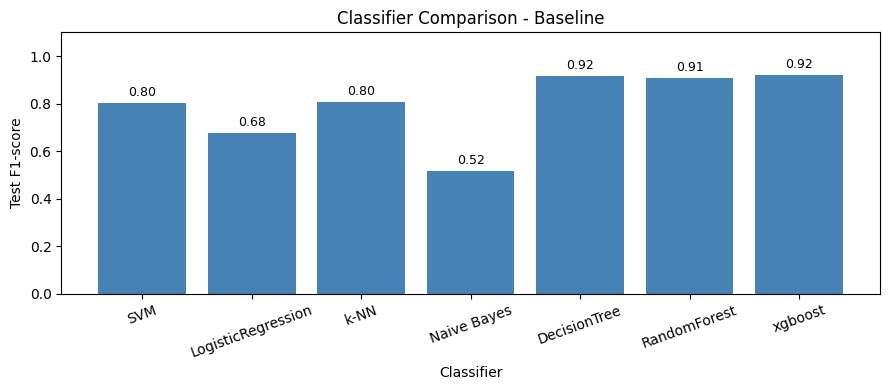

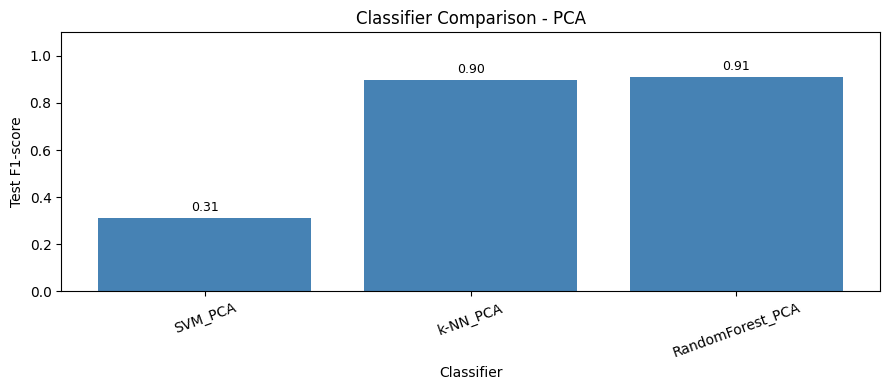

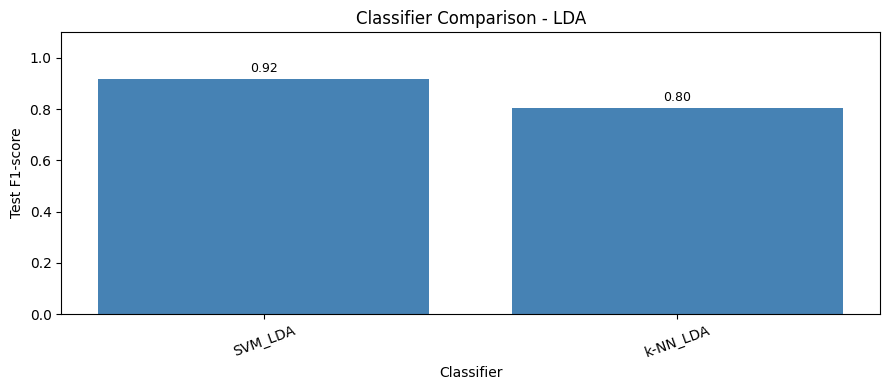

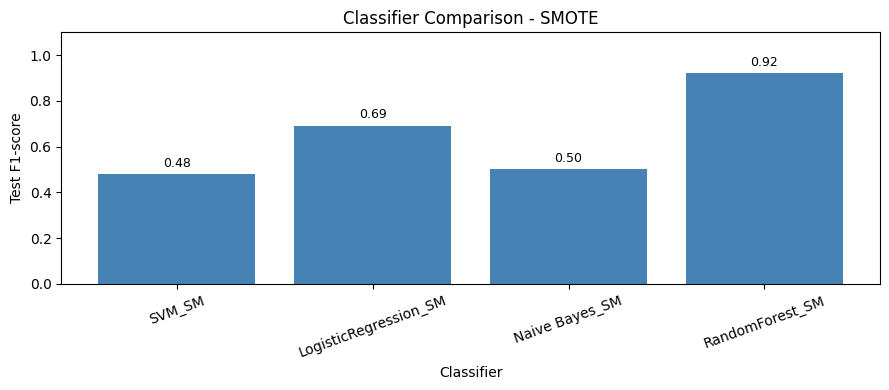

In [15]:
import matplotlib.pyplot as plt
import numpy as np

for d in all_results:
    test_label = d.get('test_type', 'Unknown')
    
    labels = [name for name in d.keys() if name != "test_type"]
    f1_scores = [float(d[name].get('f1_score', np.nan)) for name in labels]
    
    plt.figure(figsize=(9, 4))
    bars = plt.bar(labels, f1_scores, color='steelblue')

    plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)

    plt.xlabel('Classifier')
    plt.ylabel('Test F1-score')
    plt.title(f'Classifier Comparison - {test_label}')
    plt.ylim(0, 1.1)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

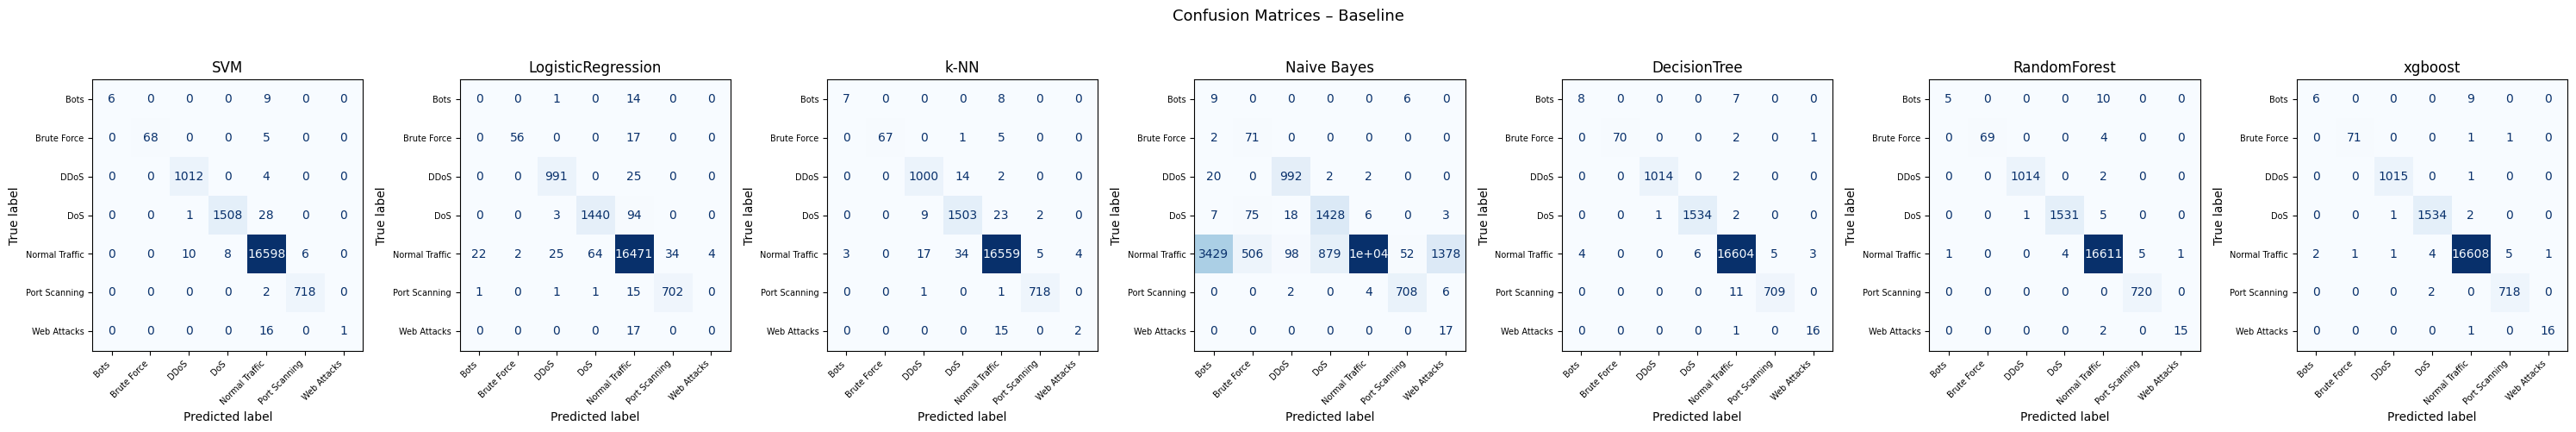

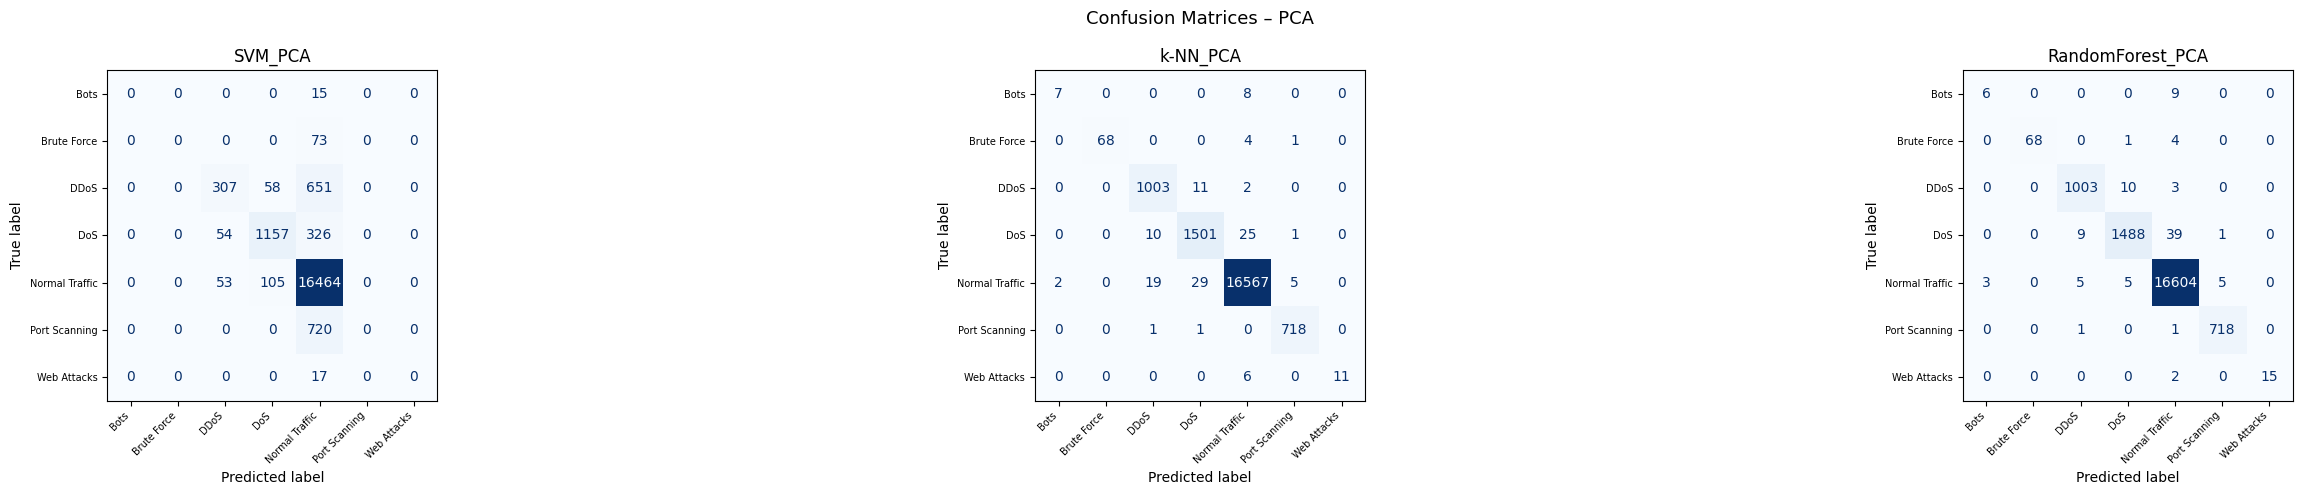

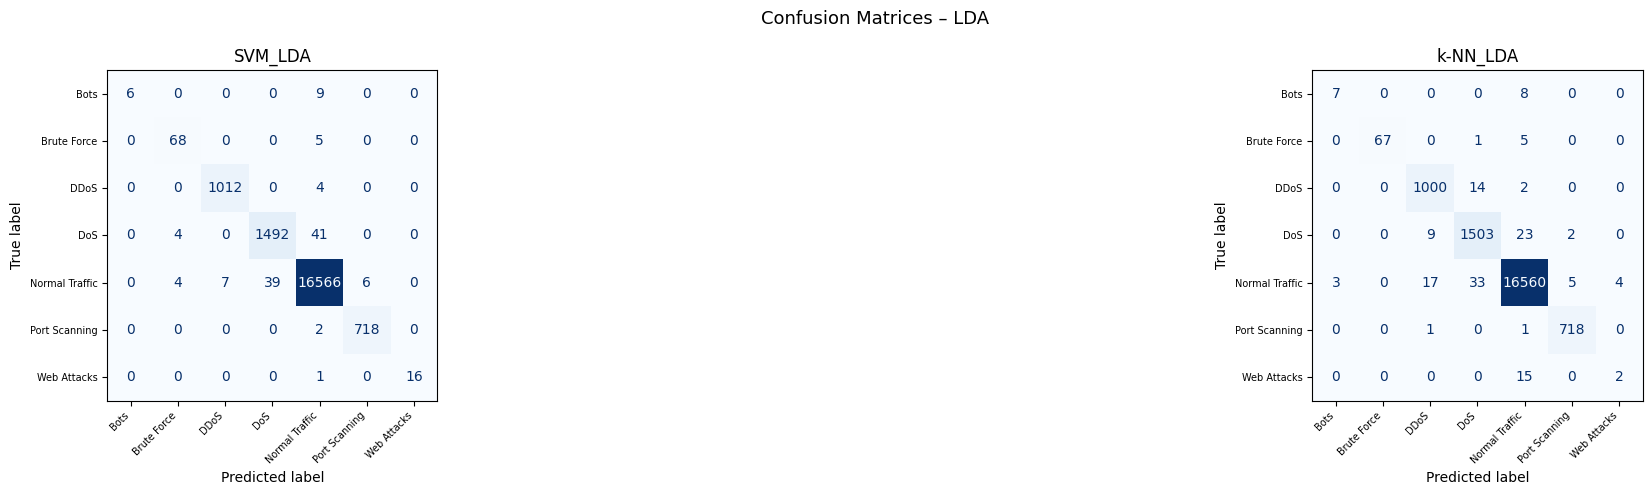

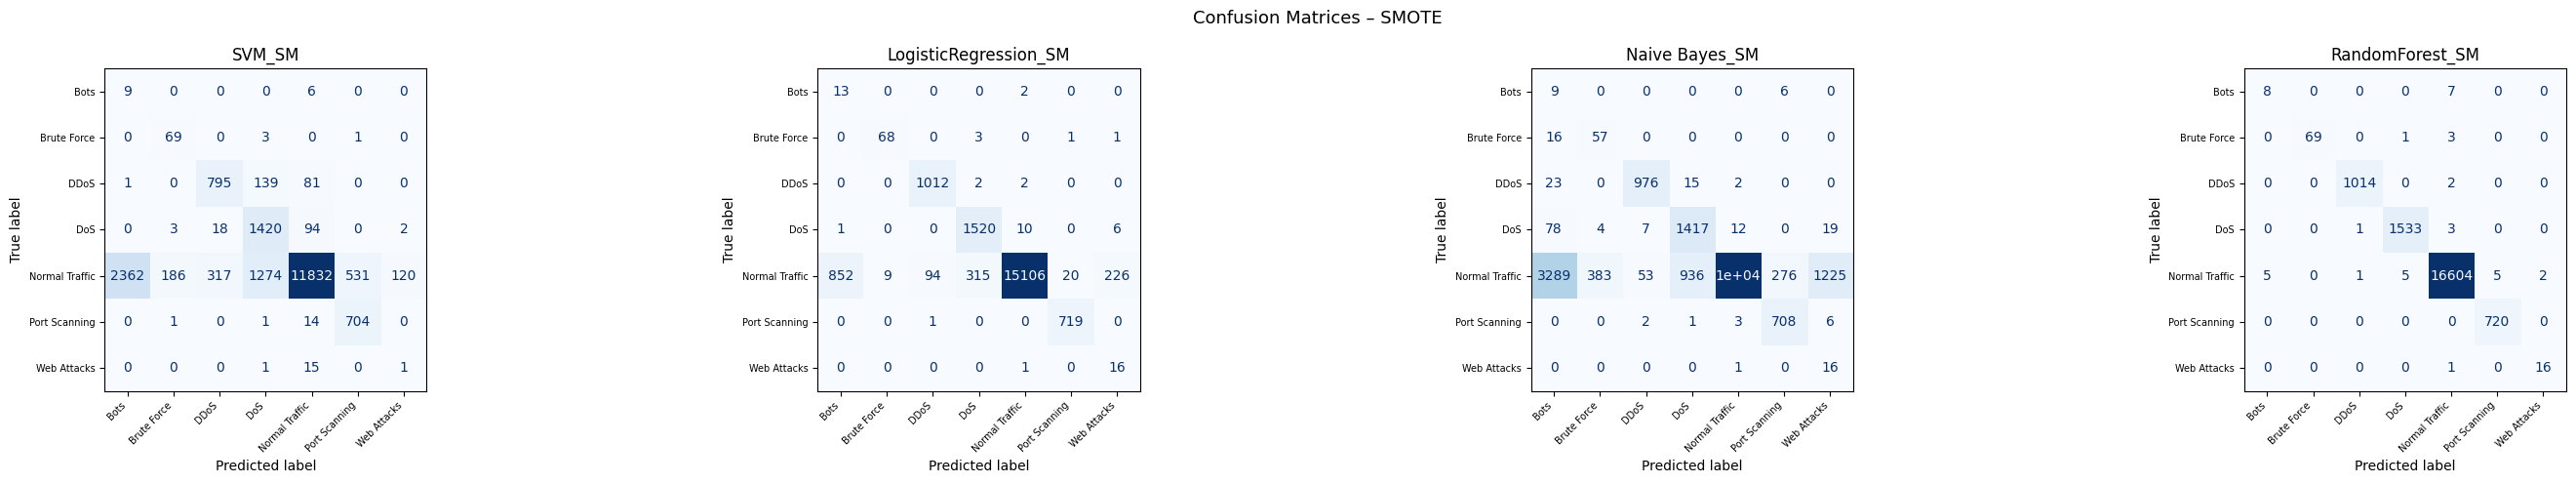

In [20]:
for d in all_results:
    labels = [name for name in d.keys() if name != "test_type"]
    fig, axes = plt.subplots(1,len(labels), figsize=(30, 5))
    fig.suptitle(f'Confusion Matrices – {d['test_type']}', fontsize=13)
    for ax, name in zip(axes, labels):
        cm = confusion_matrix(y_test, d[name]['y_pred_fs'])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.inverse_transform(np.unique(y_test)))
        disp.plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(name)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

    plt.tight_layout()
    plt.show()


In [ ]:
for d in all_results:
    test_label = d.get('test_type', 'Unknown Test')
    
    print(f"\n\n{'#'*70}")
    print(f"### CLASSIFICATION REPORTS: {test_label.upper()}")
    print(f"{'#'*70}")
    
    for model_name, metrics in d.items():
        if model_name == "test_type":
            continue
            
        print(f"\n{'='*60}")
        print(f"  {model_name.upper()}  –  {test_label}") 
        print(f"  Best params: {metrics.get('best_params', 'N/A')}")
        print('='*60)
        
        report = metrics.get('report_fs', "Report not available.")
        print(report)



######################################################################
### CLASSIFICATION REPORTS: BASELINE
######################################################################

  SVM  –  Baseline
  Best params: {'clf__C': 10000, 'clf__class_weight': None, 'clf__decision_function_shape': 'ovo', 'clf__degree': 2, 'feature_selection__k': 'all'}
                precision    recall  f1-score   support

          Bots       1.00      0.40      0.57        15
   Brute Force       1.00      0.93      0.96        73
          DDoS       0.99      1.00      0.99      1016
           DoS       0.99      0.98      0.99      1537
Normal Traffic       1.00      1.00      1.00     16622
 Port Scanning       0.99      1.00      0.99       720
   Web Attacks       1.00      0.06      0.11        17

      accuracy                           1.00     20000
     macro avg       1.00      0.77      0.80     20000
  weighted avg       1.00      1.00      1.00     20000


  LOGISTICREGRESSION  –  Baseli